<center>
  <h2>Prelims 2024</h2>
  <h3>Mani Tyagi</h3>
  <h4>200973108</h4>
</center>

In [209]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

### Part (1)

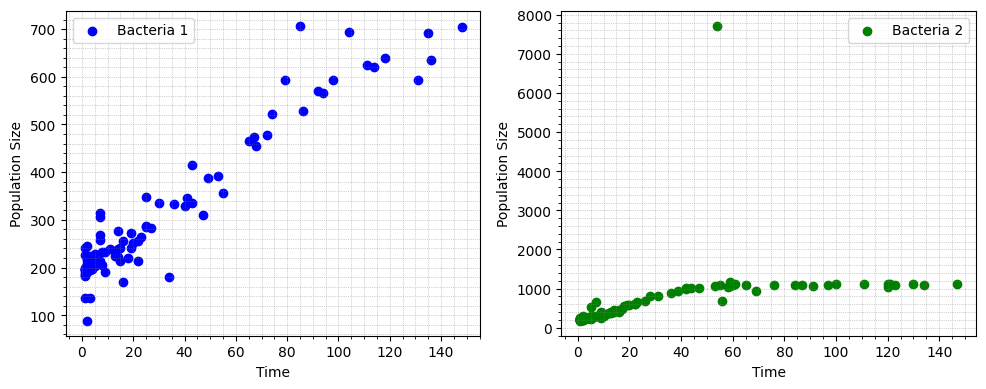

In [210]:
# Read data from files
def read_data(filename):
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# Read the data for both Bacterias
time1, population1 = read_data('bacteria1.txt')
time2, population2 = read_data('bacteria2.txt')

# Plot the raw data
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(time1, population1, label='Bacteria 1', color='blue')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(time2, population2, label='Bacteria 2', color='green')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [211]:
# Define the logistic growth model
def logistic_growth(t, K, r, P0=100):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

### Part (2)

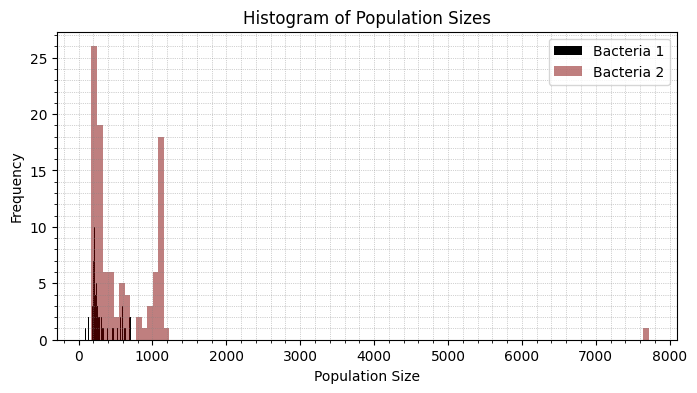

In [212]:
# Plot histograms of the data
plt.figure(figsize=(8, 4))
plt.hist(population1, bins=100, alpha=1, label='Bacteria 1', color='black')
plt.hist(population2, bins=100, alpha=0.5, label='Bacteria 2', color='maroon')
plt.xlabel('Population Size')
plt.ylabel('Frequency')
plt.title('Histogram of Population Sizes')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()
plt.show()

### Part (3)

### Metropolis Hastings

In [213]:
# Define the log likelihood function
def log_likelihood(K, r, t, population):
    predicted = logistic_growth(t, K, r)
    return -0.5 * np.sum((population - predicted) ** 2)

# Define proposal distribution for Metropolis-Hastings
def proposal(param, scale=[0.1, 0.01]):
    return [param[i] + scale[i] * np.random.randn() for i in range(len(param))]

# Metropolis-Hastings algorithm
def metropolis_hastings(t, population, iterations=100000, burn_in=10000):
    K_current, r_current = 100, 0.1
    log_likelihood_current = log_likelihood(K_current, r_current, t, population)
    
    MCMC = []
    accepted = 0
    
    for _ in range(iterations):
        K_proposal, r_proposal = proposal([K_current, r_current])
        if K_proposal <= 0 or r_proposal <= 0:
            continue
        
        log_likelihood_proposal = log_likelihood(K_proposal, r_proposal, t, population)
        log_acceptance_ratio = log_likelihood_proposal - log_likelihood_current
        if log_acceptance_ratio > 0 or np.log(np.random.rand()) < log_acceptance_ratio:
            K_current, r_current = K_proposal, r_proposal
            log_likelihood_current = log_likelihood_proposal
            accepted += 1
            
        MCMC.append([K_current, r_current])
    
    MCMC = np.array(MCMC[burn_in:])
    return MCMC

# Run MCMC for both Bacterias
MCMC1 = metropolis_hastings(time1, population1)
MCMC2 = metropolis_hastings(time2, population2)

# Print parameters for both MCMC
print("Parameters for Bacteria 1:")
print("Mean K:", np.mean(MCMC1[:, 0]))
print("Mean r:", np.mean(MCMC1[:, 1]))
print("Final K:", MCMC1[-1, 0])
print("Final r:", MCMC1[-1, 1])

print("\nParameters for Bacteria 2:")
print("Mean K:", np.mean(MCMC2[:, 0]))
print("Mean r:", np.mean(MCMC2[:, 1]))
print("Final K:", MCMC2[-1, 0])
print("Final r:", MCMC2[-1, 1])

Parameters for Bacteria 1:
Mean K: 565.6857639904741
Mean r: 0.05826879640241827
Final K: 620.2966585953307
Final r: 0.04993842654295121

Parameters for Bacteria 2:
Mean K: 1021.9554719621027
Mean r: 0.1462162637642656
Final K: 1244.7776396867746
Final r: 0.12210892398096891


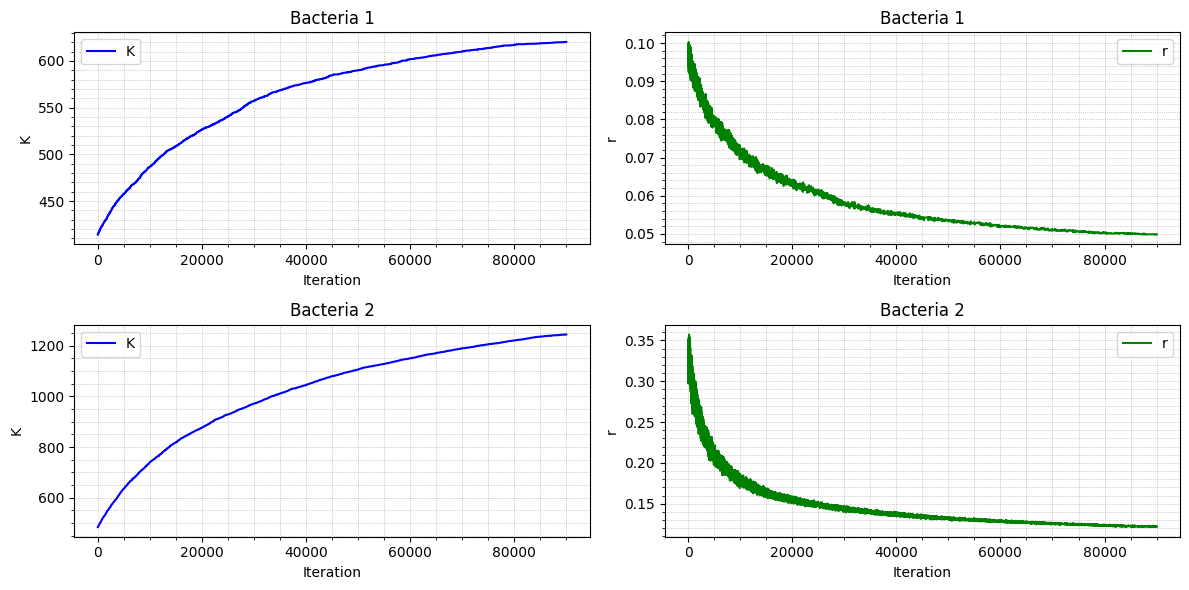

In [227]:
# Data for plotting
trace_data = [
    (MCMC1[:, 0], 'K', 'Bacteria 1', 'blue'),
    (MCMC1[:, 1], 'r', 'Bacteria 1', 'green'),
    (MCMC2[:, 0], 'K', 'Bacteria 2', 'blue'),
    (MCMC2[:, 1], 'r', 'Bacteria 2', 'green')
]

plt.figure(figsize=(12, 6))

for i, (data, label, title, color) in enumerate(trace_data):
    plt.subplot(2, 2, i+1)
    plt.plot(data, label=label, color=color)
    plt.xlabel('Iteration')
    plt.ylabel(label)
    plt.minorticks_on()
    plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()


In [215]:
def plot_logistic_growth(ax, t, population, K, r, i=0, j=0):
    if i == 1:
        color_plot = 'green'
        label_plot = 'Particle Swarm'
    
    elif i == 2:
        color_plot = 'blue'
        label_plot = 'E-M'       
        
    else:
        color_plot = 'maroon'
        label_plot = 'MCMC'
    
    if j == 0:
        ax.plot(t, population, color='black', marker='.', linestyle='', label='Original Data')    
                
    ax.plot(t, logistic_growth(t, K, r), color=color_plot, lw=2, linestyle='-', label=label_plot)
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')
    ax.minorticks_on()
    ax.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    ax.legend()

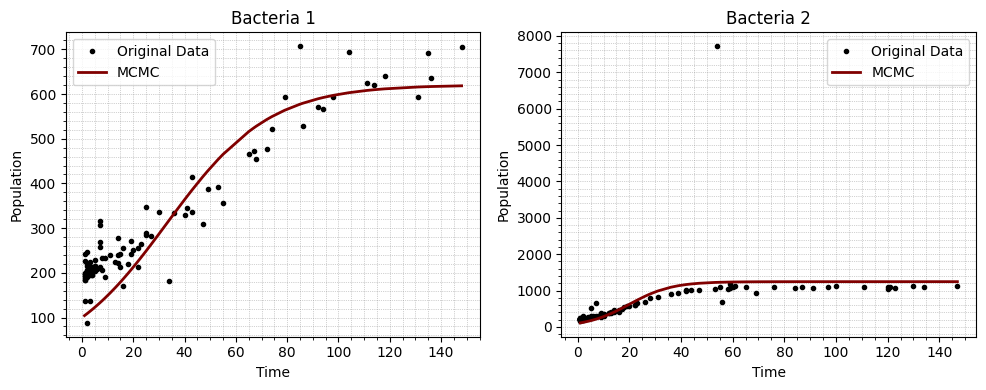

In [216]:
# Plot comparison for Bacteria 1 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, MCMC1[-1, 0], MCMC1[-1, 1])
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2 
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, MCMC2[-1, 0], MCMC2[-1, 1])

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Particle Swarm Optimization

In [217]:
# Define the fitness function (mean squared error)
def fitness_function(params, t, population):
    K, r = params
    predicted_population = logistic_growth(t, K, r)
    mse = np.mean((population - predicted_population) ** 2)
    return mse

# Particle Swarm Optimization (PSO) algorithm
def particle_swarm_optimization(t, population, num_particles=30, max_iter=1000, w=0.5, c1=1, c2=2):
    # Initialize the swarm
    swarm = np.random.rand(num_particles, 2) * [1000, 0.1]
    velocities = np.random.randn(num_particles, 2)
    personal_best_positions = np.copy(swarm)
    personal_best_scores = np.array([fitness_function(p, t, population) for p in swarm])
    global_best_position = personal_best_positions[np.argmin(personal_best_scores)]
    global_best_score = np.min(personal_best_scores)

    for i in range(max_iter):
        for j in range(num_particles):
            # Update velocity
            velocities[j] = (w * velocities[j] +
                             c1 * np.random.rand() * (personal_best_positions[j] - swarm[j]) +
                             c2 * np.random.rand() * (global_best_position - swarm[j]))

            # Update position
            swarm[j] = swarm[j] + velocities[j]

            # Update personal best
            score = fitness_function(swarm[j], t, population)
            if score < personal_best_scores[j]:
                personal_best_scores[j] = score
                personal_best_positions[j] = np.copy(swarm[j])

        # Update global best
        current_global_best_score = np.min(personal_best_scores)
        if current_global_best_score < global_best_score:
            global_best_score = current_global_best_score
            global_best_position = personal_best_positions[np.argmin(personal_best_scores)]

    return global_best_position


Final K and r values for Bacteria 1:
K: 626.7679898036876
r: 0.04919636783677755

Final K and r values for Bacteria 2:
K: 1285.2988167810975
r: 0.11928223908077329


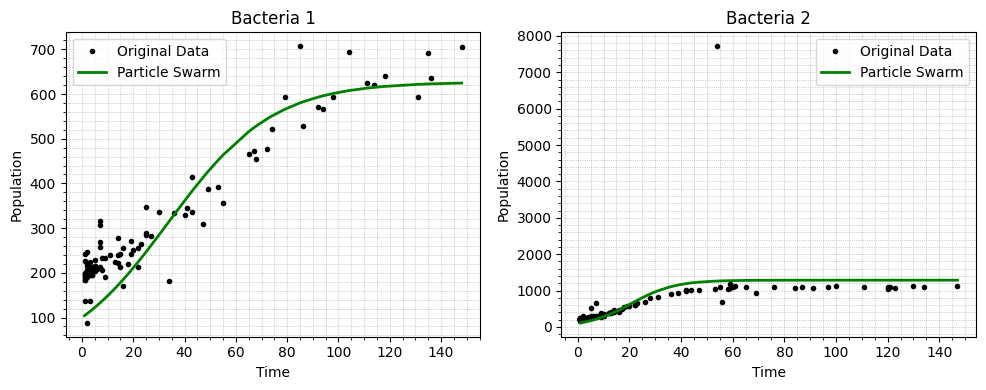

In [218]:
# Perform PSO algorithm for both Bacterias
PSO1 = particle_swarm_optimization(time1, population1)
PSO2 = particle_swarm_optimization(time2, population2)

# Print the final K and r values
print("Final K and r values for Bacteria 1:")
print("K:", PSO1[0])
print("r:", PSO1[1])

print("\nFinal K and r values for Bacteria 2:")
print("K:", PSO2[0])
print("r:", PSO2[1])

# Plot comparison for Bacteria 1 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, PSO1[0], PSO1[1], 1, 0)
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2 
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, PSO2[0], PSO2[1], 1, 0)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()

### Expectation Minimization

In [219]:
# Expectation step: compute expected values of the latent variable
def expectation_step(t, population, K, r):
    predicted = logistic_growth(t, K, r)
    return predicted

# Maximization step: update parameters based on expected values
def maximization_step(t, population, expected_population, K, r):
    epsilon = 1e-10  # Small value to avoid division by zero
    
    numerator_K = np.sum(expected_population)
    denominator_K = np.sum(1 - np.exp(-r * t))
    K_new = numerator_K / (denominator_K + epsilon)

    numerator_r = np.sum((population - expected_population) * t * np.exp(-r * t))
    denominator_r = np.sum(expected_population * t ** 2 * np.exp(-r * t))
    
    if np.abs(denominator_r) < epsilon:
        r_new = r
    else:
        r_new = numerator_r / (denominator_r + epsilon)

    return K_new, r_new

# EM algorithm with tracking of parameter values
def expectation_maximization(t, population, iterations=1000, tol=1e-12):
    # Initialize parameters
    K, r = 100, 0.01
    K_values, r_values = [K], [r]
    
    for i in range(iterations):
        # Expectation step
        expected_population = expectation_step(t, population, K, r)
        
        # Maximization step
        K_new, r_new = maximization_step(t, population, expected_population, K, r)
        
        # Append K and r values to the lists
        K_values.append(K_new)
        r_values.append(r_new)
        
        # Check for convergence
        if np.abs(K_new - K) < tol and np.abs(r_new - r) < tol:
            print(f'Converged in {i+1} iterations.')
            break
        
        K, r = K_new, r_new
    
    return K_values, r_values




In [220]:
# Perform EM algorithm with tracking for both Bacterias
EM1_k, EM1_r = expectation_maximization(time1, population1)
print("Final K and r values for Bacteria 1:")
print("K:", EM1_k[-1])
print("r:", EM1_r[-1])

print('\n')
EM2_k, EM2_r = expectation_maximization(time2, population2)
print("Final K and r values for Bacteria 2:")
print("K:", EM2_k[-1])
print("r:", EM2_r[-1])

Converged in 195 iterations.
Final K and r values for Bacteria 1:
K: 527.503808325866
r: 0.016207137612757976


Converged in 91 iterations.
Final K and r values for Bacteria 2:
K: 401.85976638441514
r: 0.0767495805548512


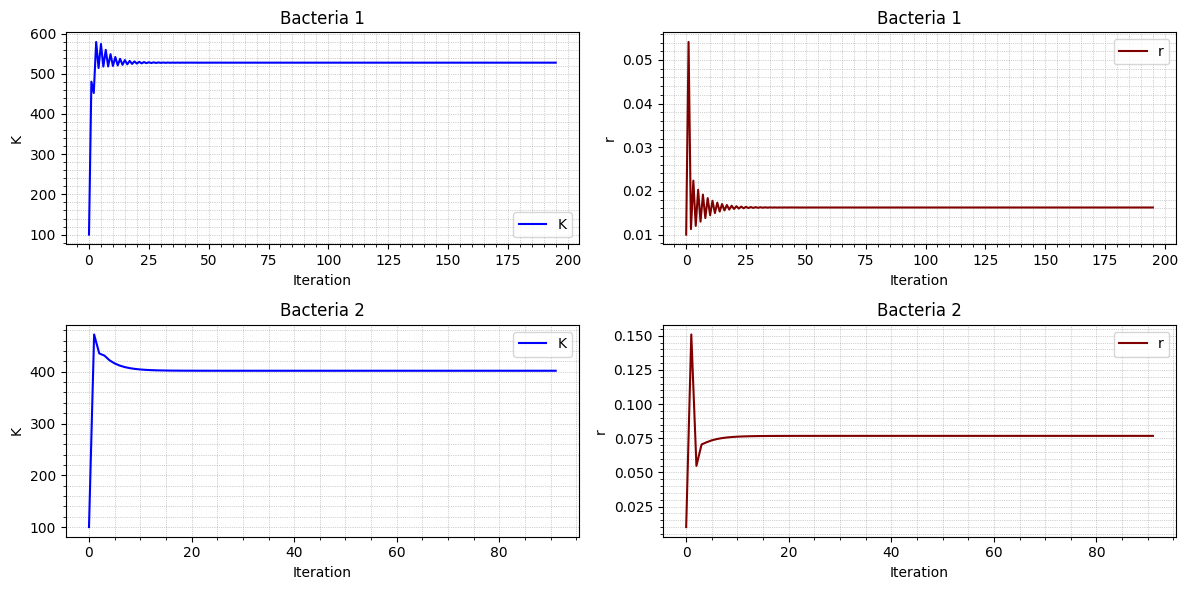

In [225]:
# Data for plotting
trace_data = [
    (EM1_k, 'K', 'Bacteria 1', 'blue'),
    (EM1_r, 'r', 'Bacteria 1', 'maroon'),
    (EM2_k, 'K', 'Bacteria 2', 'blue'),
    (EM2_r, 'r', 'Bacteria 2', 'maroon')
]

plt.figure(figsize=(12, 6))

for i, (data, label, title, color) in enumerate(trace_data):
    plt.subplot(2, 2, i+1)
    plt.plot(range(len(data)), data, label=label, color=color)
    plt.xlabel('Iteration')
    plt.ylabel(label)
    plt.minorticks_on()
    plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()


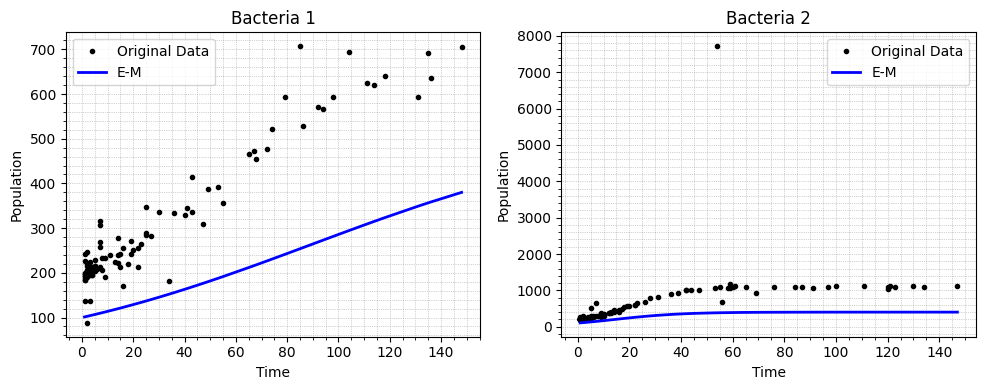

In [222]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, EM1_k[-1], EM1_r[-1], 2)
plt.title('Bacteria 1')

plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, EM2_k[-1], EM2_r[-1], 2)

plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


### Part (5)

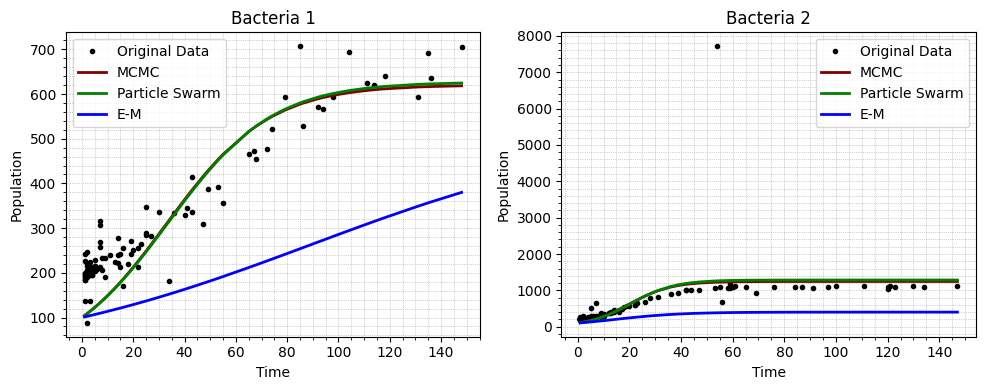

In [223]:
# Plot comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_logistic_growth(plt.gca(), time1, population1, MCMC1[-1, 0], MCMC1[-1, 1], 0)
plot_logistic_growth(plt.gca(), time1, population1, PSO1[0], PSO1[1], 1, 1)
plot_logistic_growth(plt.gca(), time1, population1, EM1_k[-1], EM1_r[-1], 2, 1)
plt.title('Bacteria 1')

# Plot comparison for Bacteria 2
plt.subplot(1, 2, 2)
plot_logistic_growth(plt.gca(), time2, population2, MCMC2[-1, 0], MCMC2[-1, 1], 0)
plot_logistic_growth(plt.gca(), time2, population2, PSO2[0], PSO2[1], 1, 1)
plot_logistic_growth(plt.gca(), time2, population2, EM2_k[-1], EM2_r[-1], 2, 1)
plt.title('Bacteria 2')

plt.tight_layout()
plt.show()


In [224]:
# Final parameter values for Bacteria 1 and 2 from MCMC 
final_K1_mcmc = MCMC1[-1, 0]
final_r1_mcmc = MCMC1[-1, 1]
final_K2_mcmc = MCMC2[-1, 0]
final_r2_mcmc = MCMC2[-1, 1]

# Final parameter values for Bacteria 1 and 2 from EM 
final_K1_em = EM1_k[-1]
final_r1_em = EM1_r[-1]
final_K2_em = EM2_k[-1]
final_r2_em = EM2_r[-1]

# Final parameter values for Bacteria 1 and 2 from PSO
final_K1_PSO = PSO1[0]
final_r1_PSO = PSO1[1]
final_K2_PSO = PSO2[0]
final_r2_PSO = PSO2[1]

# Print header for Bacteria 1
print("="*70)
print("                            Bacteria 1")
print("="*70)
print(f"{'Parameter':<12} {'MCMC':<20} {'PSO':<20} {'EM':<20}")
print("-"*70)

# Print results for Bacteria 1
print(f"{'K':<12} {final_K1_mcmc:<20.2f} {final_K1_PSO:<20.2f} {final_K1_em:<20.2f}")
print(f"{'r':<12} {final_r1_mcmc:<20.2f} {final_r1_PSO:<20.2f} {final_r1_em:<20.2f}")
print("="*70)

print("\n")
# Print header for Bacteria 2
print("="*70)
print("                            Bacteria 2")
print("="*70)
print(f"{'Parameter':<12} {'MCMC':<20} {'PSO':<20} {'EM':<20}")
print("-"*70)

# Print results for Bacteria 2
print(f"{'K':<12} {final_K2_mcmc:<20.2f} {final_K2_PSO:<20.2f} {final_K2_em:<20.2f}")
print(f"{'r':<12} {final_r2_mcmc:<20.2f} {final_r2_PSO:<20.2f} {final_r2_em:<20.2f}")
print("="*70)


                            Bacteria 1
Parameter    MCMC                 PSO                  EM                  
----------------------------------------------------------------------
K            620.30               626.77               527.50              
r            0.05                 0.05                 0.02                


                            Bacteria 2
Parameter    MCMC                 PSO                  EM                  
----------------------------------------------------------------------
K            1244.78              1285.30              401.86              
r            0.12                 0.12                 0.08                
